In [30]:
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset


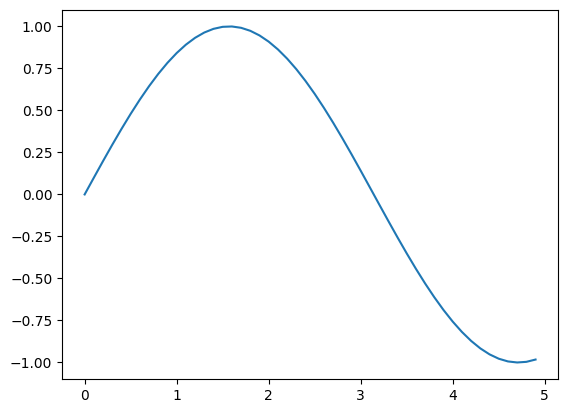

In [9]:
x = np.arange(0,5,0.1)
y = np.sin(x)
plt.plot(x,y)

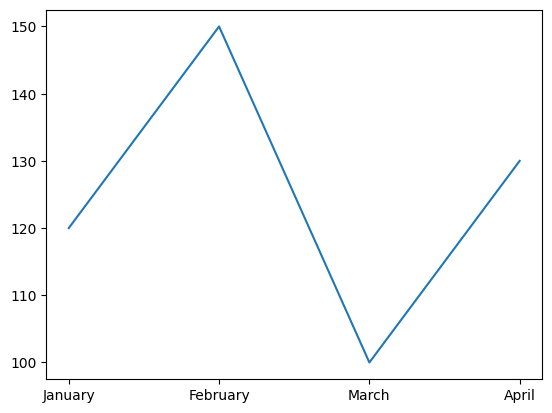

In [11]:
months = ['January', 'February', 'March', 'April']
postings = [120, 150, 100, 130]

plt.plot(months, postings)       #x, y plot

<function matplotlib.pyplot.show(close=None, block=None)>

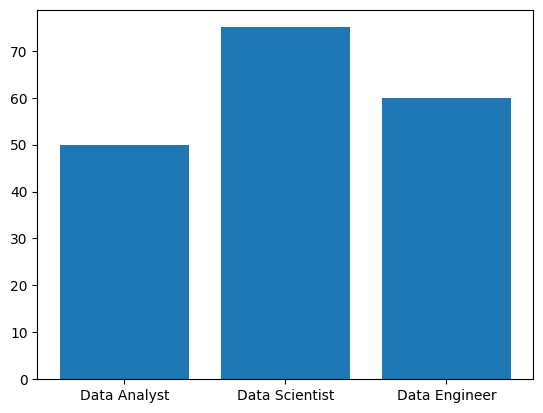

In [12]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
postings = [50, 75, 60]

plt.bar(job_titles,postings)          #Bar chart

In [88]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df.job_posted_date)

In [15]:
df.job_posted_date.head()

,job_posted_date
0,2023-06-16 13:44:15
1,2023-01-14 13:18:07
2,2023-10-10 13:14:55
3,2023-07-04 13:01:41
4,2023-08-07 14:29:36


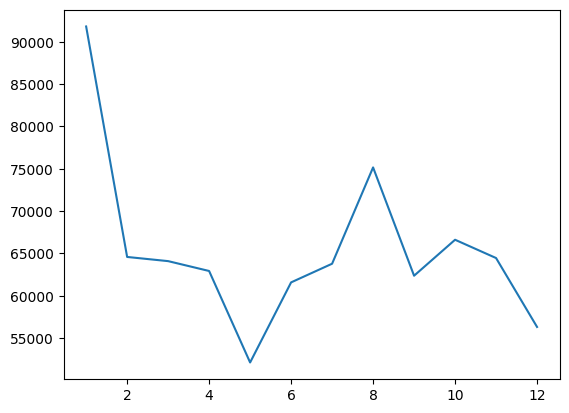

In [29]:
plt.plot(df.job_posted_date, df.job_posted_date)          #Plotting against columns of a dataframe

#aggregation of job positngs in relative to job_posted date

date_counts = df.job_posted_date.value_counts()    #its a series now. The right hand are the core portion of the series. The left is the index. Index column is not numerical order
plt.plot(date_counts.index, date_counts)                  #Date counts of the series/cores are the values. Its messy.


date_counts = df.job_posted_date.sort_index()           #Some times there are a few ones that are sepreated by seconds, so we need to aggraegate by month or something, not seconds

df['job_posted_month'] = df['job_posted_date'].dt.month
monthly_counts = df.job_posted_month.value_counts().sort_index()              #aggregate by month

plt.plot(monthly_counts.index, monthly_counts)

<BarContainer object of 5 artists>

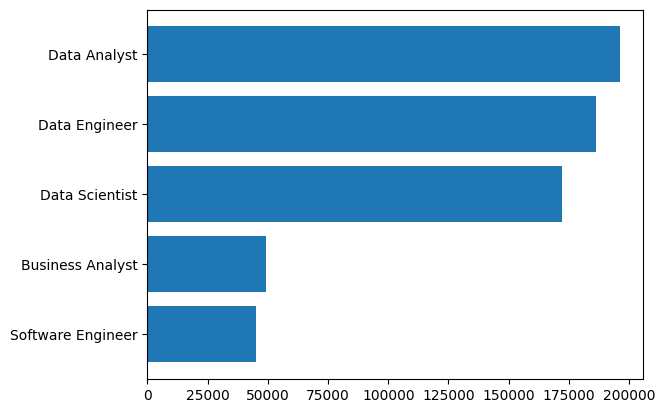

In [40]:
                                #Pandas also have a object called a series (1D array)
series = pd.Series([10,20,30,40], index = ['a','b','c','d'])
series.index
series.values

#We provide the plot a series. A column of data within a dataframe is also known as a series

job_counts = df.job_title_short.value_counts()     #Bar chart of job titles
plt.bar(job_counts.index, job_counts)      #Lots of jobs are overlapping, so we can just do the top 5 or top 10, but we can do something different

plt.barh(job_counts.index, job_counts)          #Lets do the same, but with horizontal bar chart

job_counts = job_counts.sort_values(ascending =True)   #Change the order
plt.barh(job_counts.index, job_counts)


In [86]:
country_counts = df.job_country.value_counts().head(5)
plt.bar(country_counts.index, country_counts)

avg_sal = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending=True)
plt.barh(avg_sal.index, avg_sal)

df['job_posted_month'] = df['job_posted_date'].dt.month
monthly_avg_salary = df.groupby('job_posted_month')['salary_year_avg'].mean().sort_index()
plt.plot(monthly_avg_salary.index, monthly_avg_salary.values, color='green')



,salary_year_avg
job_posted_month,
1,123007.422072
2,122913.927237
3,122947.810047
4,121856.551050
5,123656.747729
6,124321.135360
7,123470.572994
8,125819.429100
9,125222.984594


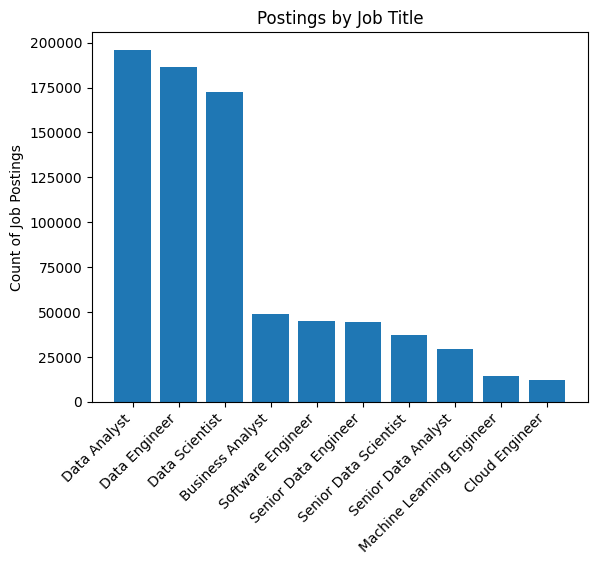

In [96]:
job_counts = df.job_title_short.value_counts()                                                             #Labeling

                                                      #We stacked all different things before we "show" it
plt.bar(job_counts.index, job_counts)
plt.title('Postings by Job Title')                     #Add title
plt.ylabel('Count of Job Postings')                    #Labels y axis
plt.xticks(rotation = 45, ha = 'right')                              #Rotate the x axis labels by degrees or horizontal alignment (align horizontally to right/left/center)
plt.show()

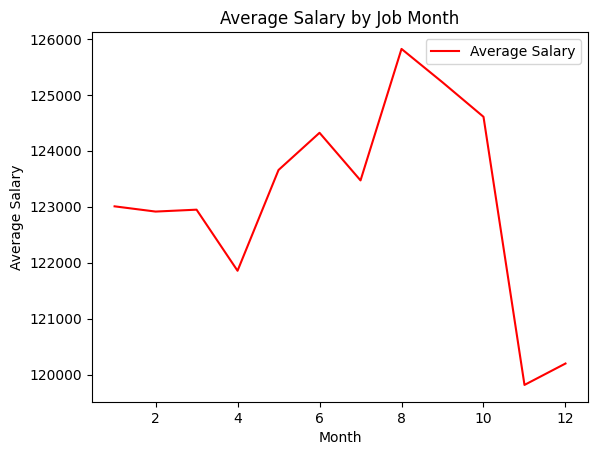

In [105]:
country_counts = df.job_country.value_counts().head(5)
plt.bar(country_counts.index, country_counts)
plt.xlabel('Country')
plt.ylabel('Number of Postings')
plt.title('Number of Jobs per Country')
plt.xticks(rotation = 45, ha = 'right')
plt.show()

avg_sal = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending=True)
plt.barh(avg_sal.index, avg_sal)
plt.xlabel('Average Salary')
plt.title('Average Salary by Job Title')
plt.show()

df['job_posted_month'] = df['job_posted_date'].dt.month
monthly_avg_salary = df.groupby('job_posted_month')['salary_year_avg'].mean().sort_index()
plt.plot(monthly_avg_salary.index, monthly_avg_salary.values, color='red', label = 'Average Salary')
plt.xlabel('Month')
plt.ylabel('Average Salary')
plt.title('Average Salary by Job Month')
plt.legend()
plt.show()